# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: O arquivo CSV foi importado e convertido em uma DataFrame. Depois, foi feito o calculo do número de caracteres dos nomes dos genes utilizando str.len(). Em seguida, foi criada uma tabela de frequência com value_counts(), e então os valores foram organizado com o sort_index(). Essa tabela foi convertida em DataFrame. Com isso foi gerado um gráfico de barras dessa tabela com o matplotlib.

## 02 – Desenhe o fluxograma da resposta:

<img src="./Frequencia aleatoria.png" width="400" />

## 03 – Escreva o programa em Python:

                frequencia
num_caracteres            
4                        3
5                        2


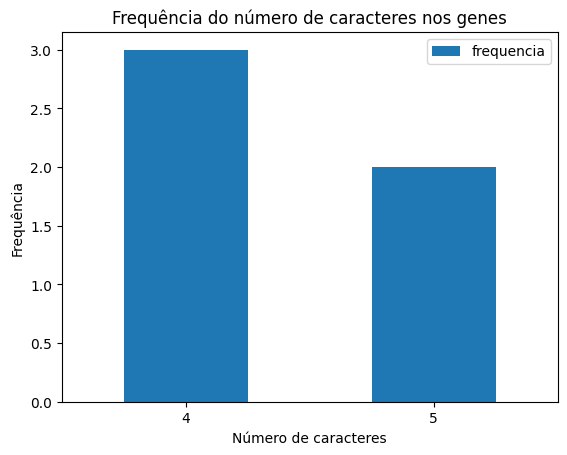

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('genes.csv', index_col=0)
df['num_caracteres'] = df.index.str.len()
freq = df['num_caracteres'].value_counts().sort_index()
df_freq = pd.DataFrame({'frequencia': freq})
print(df_freq)

df_freq.plot(kind='bar')
plt.title('Frequência do número de caracteres nos genes')
plt.xlabel('Número de caracteres')
plt.ylabel('Frequência')
plt.xticks(rotation=0)
plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.:O arquivo CSV foi importado e convertido em um DataFrame. Em seguida, foi realizado o cálculo do número de caracteres dos nomes dos genes utilizando o método str.len() mantendo a ordem dos dados. Depois, foi criada uma tabela de frequência com o método value_counts(), e os valores foram organizados com sort_index(). Essa frequência foi então inserida na DataFrame por meio do método map(). Por fim, foi gerado um gráfico da tabela utilizando o matplotlib.

## 05 – Desenhe o fluxograma da resposta:

<img src="./ultima.png" width="400" />

## 06 – Escreva o programa em Python:

                Freq Absoluta  Freq Relativa
num_caracteres                              
4                           3            0.6
5                           2            0.4


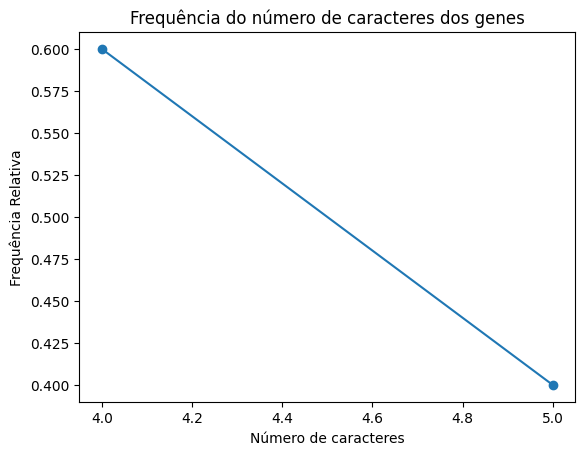

In [15]:
df = pd.read_csv('genes.csv', index_col=0)
df['num_caracteres'] = df.index.str.len()
freq_abs = df['num_caracteres'].value_counts().sort_index()
freq_rel = freq_abs / freq_abs.sum()
tabela_freq = pd.DataFrame({
    'Freq Absoluta': freq_abs,
    'Freq Relativa': freq_rel
})
df['freq_abs'] = df['num_caracteres'].map(freq_abs)
df['freq_rel'] = df['num_caracteres'].map(freq_rel)
print(tabela_freq)

fig, ax1 = plt.subplots()
ax1.plot(tabela_freq.index, tabela_freq['Freq Relativa'], marker='o')
ax1.set_ylabel('Frequência Relativa')
plt.title('Frequência do número de caracteres dos genes')
ax1.set_xlabel('Número de caracteres')
plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [4]:
df = pd.read_csv('genes.csv', index_col=0)

df = df.drop(columns=['iniciais', 'qtd_a', 'se_tem_hu'])

df['Amostra 1'] = 1

df

,numero de caracteres,Amostra 1
BRCA1,5,1
TP53,4,1
EGFR,4,1
CHEK2,5,1
PTEN,4,1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [5]:
import numpy as np

df = pd.read_csv('genes.csv', index_col=0)
df['num_caracteres'] = df.index.str.len()
df['Amostra 1'] = 1
amostra2 = np.random.randint(1, 10, len(df))
df['Amostra 2'] = amostra2
freq_abs = pd.Series(amostra2).value_counts().sort_index()
freq_rel = freq_abs / freq_abs.sum()
freq_abs_acum = freq_abs.cumsum()
freq_rel_acum = freq_rel.cumsum()
tabela = pd.DataFrame({
    'Freq Absol Simp': freq_abs,
    'Freq Relat Simp': freq_rel,
    'Freq Absol Acum': freq_abs_acum,
    'Freq Relat Acum': freq_rel_acum
})

tabela.loc['Total'] = [
    freq_abs.sum(),
    freq_rel.sum(),
    '',
    ''
]
print("DataFrame com Amostra 2:")
print(df)

print("\nTabela de frequência da Amostra 2:")
tabela

DataFrame com Amostra 2:
       numero de caracteres iniciais  qtd_a  se_tem_hu  num_caracteres  \
BRCA1                     5       BR      1      False               5   
TP53                      4       TP      0      False               4   
EGFR                      4       EG      0      False               4   
CHEK2                     5       CH      0      False               5   
PTEN                      4       PT      0      False               4   

       Amostra 1  Amostra 2  
BRCA1          1          7  
TP53           1          5  
EGFR           1          8  
CHEK2          1          6  
PTEN           1          5  

Tabela de frequência da Amostra 2:


,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum
5,2,0.4,2,0.4
6,1,0.2,3,0.6
7,1,0.2,4,0.8
8,1,0.2,5,1.0
Total,5,1.0,,


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [6]:
df = pd.read_csv('genes.csv', index_col=0)
df['num_caracteres'] = df.index.str.len()
df['Amostra 1'] = 1
df['Amostra 2'] = np.random.randint(1, 10, len(df))
for i in range(3, 7):
    df[f'Amostra {i}'] = np.random.randint(1, 10, len(df))

print("DataFrame final:")
df
for i in range(2, 7):
    print(f"\nTabela de Frequência - Amostra {i}")
    
    s = df[f'Amostra {i}']
    
    freq_abs = s.value_counts().sort_index()
    freq_rel = freq_abs / freq_abs.sum()
    freq_abs_acum = freq_abs.cumsum()
    freq_rel_acum = freq_rel.cumsum()
    
    tabela = pd.DataFrame({
        'Freq Absol Simp': freq_abs,
        'Freq Relat Simp': freq_rel,
        'Freq Absol Acum': freq_abs_acum,
        'Freq Relat Acum': freq_rel_acum
    })
    
    tabela.loc['Total'] = [freq_abs.sum(), freq_rel.sum(), '', '']
    
    print(tabela)

DataFrame final:

Tabela de Frequência - Amostra 2
           Freq Absol Simp  Freq Relat Simp Freq Absol Acum Freq Relat Acum
Amostra 2                                                                  
3                        1              0.2               1             0.2
5                        1              0.2               2             0.4
7                        2              0.4               4             0.8
9                        1              0.2               5             1.0
Total                    5              1.0                                

Tabela de Frequência - Amostra 3
           Freq Absol Simp  Freq Relat Simp Freq Absol Acum Freq Relat Acum
Amostra 3                                                                  
3                        1              0.2               1             0.2
6                        1              0.2               2             0.4
7                        1              0.2               3             0.6
8  

## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

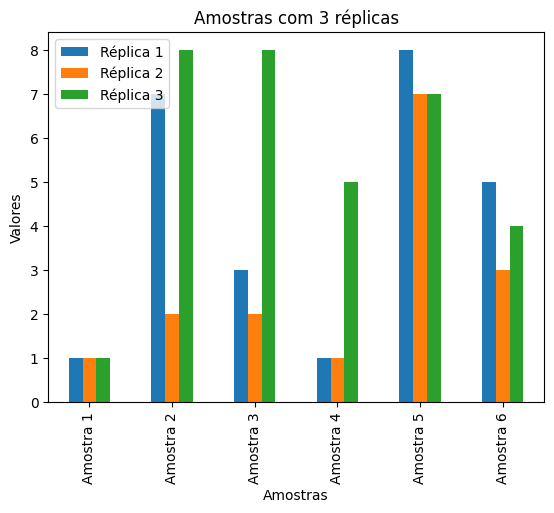

In [7]:
df = pd.read_csv('genes.csv', index_col=0)
df['num_caracteres'] = df.index.str.len()
df['Amostra 1'] = 1
for i in range(2, 7):
    df[f'Amostra {i}'] = np.random.randint(1, 10, len(df))

replicas = df[['Amostra 1','Amostra 2','Amostra 3',
               'Amostra 4','Amostra 5','Amostra 6']].iloc[:3]

replicas.T.plot(kind='bar')

plt.title('Amostras com 3 réplicas')
plt.xlabel('Amostras')
plt.ylabel('Valores')
plt.legend(['Réplica 1', 'Réplica 2', 'Réplica 3'])

plt.show()